In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("car_price_prediction_.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset:
(2500, 10)

Column names:
Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='str')

Data types:
Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage           int64
Condition           str
Price           float64
Model               str
dtype: object

Missing values:
Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


In [7]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [10]:
print(df.columns.tolist())

['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']


In [13]:
print(df.columns.tolist())

['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']


In [16]:
print("Price statistics")
print(df["Price"].describe())

Price statistics
count     2500.000000
mean     52638.022532
std      27295.833455
min       5011.270000
25%      28908.485000
50%      53485.240000
75%      75838.532500
max      99982.590000
Name: Price, dtype: float64


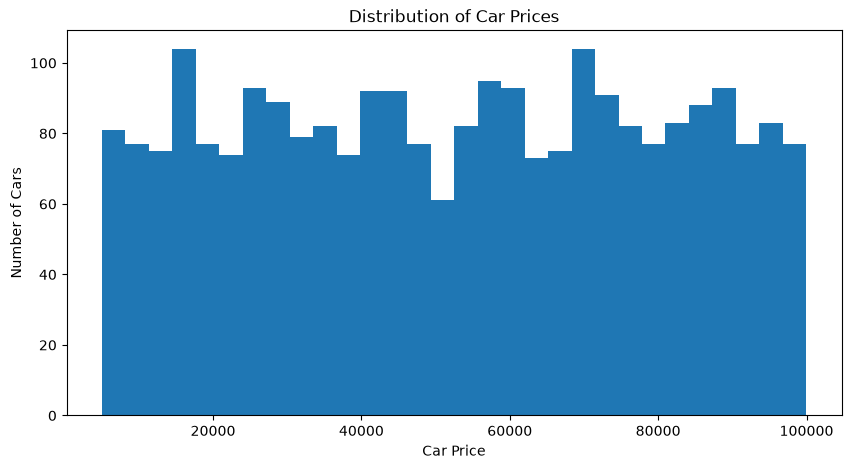

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(df["Price"], bins=30)

plt.title("Distribution of Car Prices")
plt.xlabel("Car Price")
plt.ylabel("Number of Cars")

plt.show()

In [19]:
print(df["Price"].head())

0    26613.92
1    14679.61
2    44402.61
3    86374.33
4    73577.10
Name: Price, dtype: float64


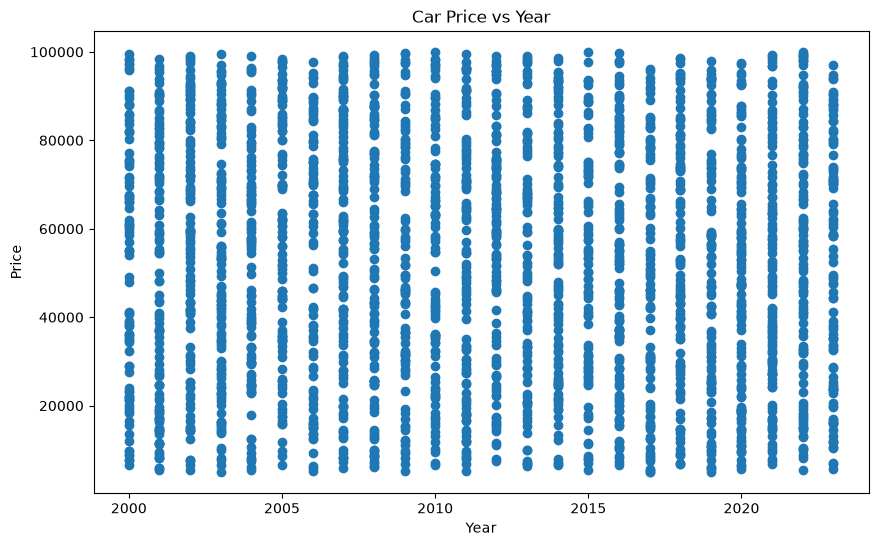

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Year"], df["Price"])

plt.title("Car Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [25]:
# Select features and target

X = df[["Year", "Engine Size", "Mileage", "Condition"]]
y = df["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Year  Engine Size  Mileage Condition
0  2016          2.3   114832       New
1  2018          4.4   143190      Used
2  2013          4.5   181601       New
3  2011          4.1    68682       New
4  2009          2.6   223009  Like New

Target:
0    26613.92
1    14679.61
2    44402.61
3    86374.33
4    73577.10
Name: Price, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2000, 4)
Testing data: (500, 4)


In [29]:
# Convert categorical columns into numerical values
X = pd.get_dummies(
    df[["Year", "Engine Size", "Mileage", "Condition"]],
    drop_first=True
)

y = df["Price"]

print("Features converted successfully!")
print(X.head())

Features converted successfully!
   Year  Engine Size  Mileage  Condition_New  Condition_Used
0  2016          2.3   114832           True           False
1  2018          4.4   143190          False            True
2  2013          4.5   181601           True           False
3  2011          4.1    68682           True           False
4  2009          2.6   223009          False           False


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2000, 5)
Testing data: (500, 5)


In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [32]:
# Predict prices for the test data
y_pred = model.predict(X_test)

print("Predicted prices:")
print(y_pred[:10])

Predicted prices:
[52856.55375252 51505.71682179 52509.92278931 53363.15974936
 51887.63072006 50601.8403989  51603.89013223 52408.4307499
 52701.68902909 52365.91135771]


In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 23738.532103688834
Root Mean Squared Error: 27512.419429421443
R² Score: 0.0008185686697997907


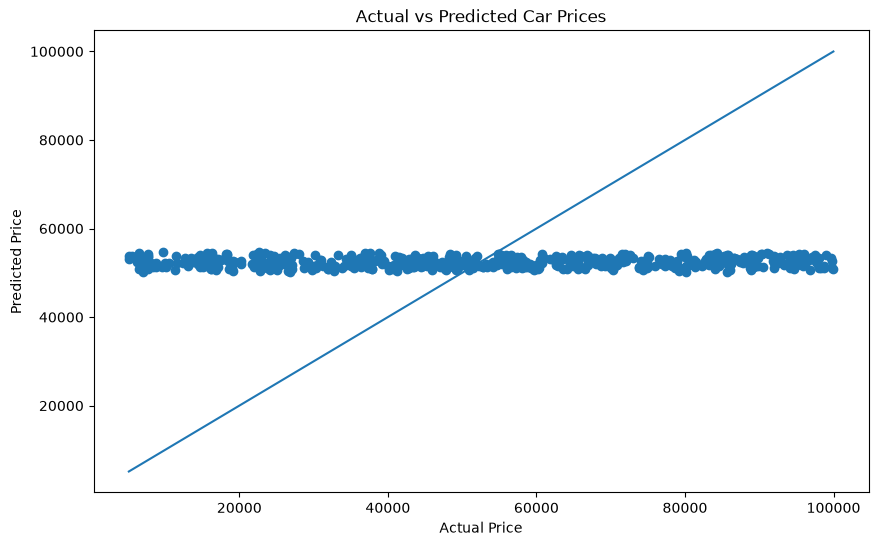

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()